# Object Embedding Retrieval
**Pipeline:** COCO128 → YOLO detection → crop extraction → ResNet50 fine-tuning with triplet loss → FAISS indexing → retrieval demo → UMAP visualization

Run sections **1 through 6 once** to build the index. After that, only run sections **7 and 8** for querying and visualization.

---
## Section 1 — Imports & Configuration
Run once. All hyperparameters and paths live here — change them here, not deep in the code.

In [1]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import faiss
import umap
from ultralytics import YOLO

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path(".")                  # project root
CROPS_DIR   = ROOT / "crops"             # extracted object crops
EMB_DIR     = ROOT / "embeddings"        # saved vectors + metadata
INDEX_DIR   = ROOT / "index"             # FAISS index
CKPT_DIR    = ROOT / "checkpoints"       # model checkpoints

for d in [CROPS_DIR, EMB_DIR, INDEX_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Detection config ─────────────────────────────────────────────────────────
YOLO_CONF       = 0.4    # minimum confidence for a detection to be kept
MIN_CROP_SIZE   = 32     # crops smaller than this (px) are discarded — too noisy

# ── Embedding model config ───────────────────────────────────────────────────
EMBED_DIM       = 128    # output dimension of the projection head
IMG_SIZE        = 224    # input size expected by ResNet50

# ── Training config ──────────────────────────────────────────────────────────
TRIPLET_MARGIN  = 0.3    # how far apart negative pairs must be pushed
BATCH_SIZE      = 64     # number of triplets per batch
NUM_EPOCHS      = 10     # increase for COCO train2017
LR              = 2e-4   # learning rate for unfrozen layers
LR_HEAD         = 1e-3   # higher LR for the projection head (trained from scratch)

# ── Retrieval config ─────────────────────────────────────────────────────────
TOP_K           = 5      # number of results to return per query

print("\nConfiguration loaded.")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\golde\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 17.1 GB

Configuration loaded.


---
## Section 2 — Download COCO128 & Run YOLO Detection
Downloads COCO128 automatically via ultralytics (one-time, ~25MB).
Runs YOLOv8n on every image and saves bounding boxes.

**To switch to COCO train2017:** change `dataset_path` below to your COCO train2017 images folder. Everything else stays identical.

In [36]:
# ── Download COCO128 ─────────────────────────────────────────────────────────
# ultralytics downloads and extracts COCO128 automatically on first use
yolo_model = YOLO("yolov8n.pt")  # nano — fastest, sufficient for crop extraction

# After first run, COCO128 images are at: datasets/coco128/images/train2017/
dataset_path = Path("datasets/coco128/images/train2017")

if not dataset_path.exists():
    os.makedirs(dataset_path.parent, exist_ok=True)
    # Trigger download by running on a dummy image — ultralytics handles the rest
    print("COCO128 not found locally, triggering download...")
    yolo_model.predict(source="https://ultralytics.com/images/bus.jpg", save=False)
    # Now manually download COCO128
    import urllib.request
    url = "https://ultralytics.com/assets/coco128.zip"
    print("Downloading COCO128...")
    urllib.request.urlretrieve(url, "datasets/coco128.zip")
    shutil.unpack_archive("datasets/coco128.zip", "datasets/")
    os.remove("datasets/coco128.zip")
    print("COCO128 ready.")

image_paths = sorted(list(dataset_path.glob("*.jpg")))
print(f"Dataset path: {dataset_path}")
#print(str(image_paths[2]))  # show an example image path
print(f"Found {len(image_paths)} images in dataset.")

Dataset path: datasets\coco128\images\train2017
Found 128 images in dataset.


In [32]:
# ── Run detection on all images ───────────────────────────────────────────────
# YOLO returns bounding boxes + class labels for every detected object.
# We store results as a list of dicts — one dict per image.

detection_results = []  # will hold {image_path, boxes, class_ids, class_names, confs}

print("Running YOLOv8n detection on all images...")
results = yolo_model.predict(
    source=str(dataset_path),
    conf=YOLO_CONF,
    save=False,       # don't save annotated images, we only need the box data
    verbose=False
)

for r, img_path in zip(results, image_paths):
    boxes      = r.boxes.xyxy.cpu().numpy()   # [x1, y1, x2, y2] in pixels
    class_ids  = r.boxes.cls.cpu().numpy().astype(int)
    confs      = r.boxes.conf.cpu().numpy()
    class_names = [r.names[c] for c in class_ids]
    detection_results.append({
        "image_path": str(img_path),
        "boxes": boxes,
        "class_ids": class_ids,
        "class_names": class_names,
        "confs": confs
    })
print("Detection complete.")
print(detection_results[0])  # print first result as example
total_detections = sum(len(r["boxes"]) for r in detection_results)
print(f"Detection complete. Total objects found: {total_detections}")

Running YOLOv8n detection on all images...
Detection complete.
{'image_path': 'datasets\\coco128\\images\\train2017\\000000000009.jpg', 'boxes': array([[     306.12,    0.039932,      628.63,      238.08],
       [     253.68,      233.62,      566.41,      479.12],
       [          0,      7.7275,      471.14,      465.01],
       [    0.79199,      182.68,      628.69,      479.34],
       [    0.33185,      112.99,      229.98,      303.59]], dtype=float32), 'class_ids': array([45, 50, 45, 45, 52]), 'class_names': ['bowl', 'broccoli', 'bowl', 'bowl', 'hot dog'], 'confs': array([     0.9274,     0.76451,     0.63421,     0.42825,     0.40181], dtype=float32)}
Detection complete. Total objects found: 463


---
## Section 3 — Crop Extraction
For every bounding box from YOLO, crop that region out of the original image and save it as a PNG.
Also builds a manifest (JSON) mapping each crop to its class label and source image.

In [9]:
# ── Extract and save crops ────────────────────────────────────────────────────
# Each crop gets a unique filename: {class_name}_{image_idx}_{box_idx}.png
# The manifest records metadata for every crop — used later during training and retrieval.

manifest = []  # list of {crop_path, class_id, class_name, source_image}

print("Extracting crops...")
for img_idx, result in enumerate(tqdm(detection_results)):
    img = Image.open(result["image_path"]).convert("RGB")
    w, h = img.size

    for box_idx, (box, cls_id, cls_name) in enumerate(
        zip(result["boxes"], result["class_ids"], result["class_names"])
    ):
        x1, y1, x2, y2 = box

        # Clamp to image boundaries (YOLO can predict slightly outside)
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(w, int(x2)), min(h, int(y2))

        # Skip crops that are too small — they're usually background noise
        if (x2 - x1) < MIN_CROP_SIZE or (y2 - y1) < MIN_CROP_SIZE:
            continue

        crop = img.crop((x1, y1, x2, y2))
        crop_filename = f"{cls_name}_{img_idx:04d}_{box_idx:02d}.png"
        crop_path = CROPS_DIR / crop_filename
        crop.save(crop_path)

        manifest.append({
            "crop_path": str(crop_path),
            "class_id": int(cls_id),
            "class_name": cls_name,
            "source_image": result["image_path"]
        })

# Save manifest to disk — needed by later sections
with open(EMB_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved {len(manifest)} crops to {CROPS_DIR}")
print(f"Manifest saved to {EMB_DIR / 'manifest.json'}")

# Show class distribution
class_counts = defaultdict(int)
for m in manifest:
    class_counts[m["class_name"]] += 1
print(f"\nClasses present: {len(class_counts)}")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1])[:20]:
    print(f"  {cls:20s}: {count}")

Extracting crops...


100%|██████████| 128/128 [00:05<00:00, 22.92it/s]

Saved 358 crops to crops
Manifest saved to embeddings\manifest.json

Classes present: 63
  person              : 115
  donut               : 19
  bowl                : 14
  elephant            : 12
  giraffe             : 10
  dining table        : 10
  cup                 : 9
  teddy bear          : 7
  potted plant        : 7
  dog                 : 7
  chair               : 7
  bottle              : 7
  pizza               : 6
  bird                : 6
  carrot              : 6
  umbrella            : 5
  clock               : 5
  car                 : 5
  motorcycle          : 5
  cake                : 5


---
## Section 4 — Model Architecture
Defines the embedding model: ResNet50 backbone with a projection head.

**Frozen:** layers 1–6 (basic vision features, no need to retrain)
**Unfrozen:** layer4 (last ResNet block) + projection head (trained from scratch)

The projection head compresses 2048 dims → 128 dims and L2-normalizes the output,
which makes cosine similarity equivalent to dot product — required for FAISS inner product search.

In [10]:
class EmbeddingModel(nn.Module):
    """
    ResNet50 backbone + projection head for metric learning.
    
    Architecture:
        Input image (3 x 224 x 224)
        → ResNet50 (frozen layers 1-3, unfrozen layer4)
        → Global average pool → 2048-dim vector
        → Projection head: Linear(2048→512) → BN → ReLU → Linear(512→128)
        → L2 normalization
        → 128-dim unit vector (the embedding)
    """
    def __init__(self, embed_dim=128, freeze_until="layer3"):
        super().__init__()

        # Load ResNet50 pretrained on ImageNet
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Remove the final classification layer (fc) — we don't want class scores
        # backbone.fc outputs 1000 class logits; we replace it with identity
        # and add our own projection head instead
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Freeze all backbone layers first, then selectively unfreeze
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze layer4 (the last residual block, ~11M params)
        # This block learns high-level semantic features — the most relevant for similarity
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Projection head — trained entirely from scratch
        # BatchNorm stabilizes training when combined with frozen layers
        self.projection = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        # Extract features from backbone (2048-dim after global avg pool)
        features = self.backbone(x)          # (batch, 2048)
        
        # Project to lower-dimensional embedding space
        embeddings = self.projection(features)  # (batch, 128)
        
        # L2 normalize — puts all embeddings on a unit hypersphere
        # After this, cosine similarity = dot product, which FAISS handles efficiently
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings


# Instantiate and move to GPU
model = EmbeddingModel(embed_dim=EMBED_DIM).to(DEVICE)

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  (layer4 + projection head)")
print(f"Frozen parameters:    {frozen_params:,}  (layers 1-3)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\golde/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 61.2MB/s]


Total parameters:     24,623,808
Trainable parameters: 16,080,512  (layer4 + projection head)
Frozen parameters:    8,543,296  (layers 1-3)


---
## Section 5 — Dataset, Triplet Mining & Training

### What is a triplet?
A triplet is three images: **(anchor, positive, negative)**
- **Anchor:** any crop
- **Positive:** a different crop of the **same class** as the anchor
- **Negative:** a crop of a **different class**

### Triplet loss
The loss pushes: `distance(anchor, positive) + margin < distance(anchor, negative)`

In plain terms: the negative must be at least `margin` further away than the positive.
If it already is, loss = 0 for that triplet. Only "violated" triplets contribute to the gradient.

### Hard negative mining
Random negatives are too easy — the model ignores them quickly.
Hard negatives are the negatives the model currently puts **closest** to the anchor.
Training on hard negatives forces the model to sharpen class boundaries.

In [14]:
# ── Image transforms ──────────────────────────────────────────────────────────
# Training transforms include augmentation to improve generalization
# Validation/inference transforms are deterministic (no random ops)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          # left-right flip, 50% chance
    transforms.ColorJitter(                      # random brightness/contrast/saturation
        brightness=0.3, contrast=0.3, saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(                        # ImageNet mean/std — required for pretrained ResNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ── Triplet Dataset ───────────────────────────────────────────────────────────
class TripletDataset(Dataset):
    """
    Builds triplets (anchor, positive, negative) on the fly from the crop manifest.
    
    Strategy: online semi-hard mining
    - For each anchor, randomly pick a positive from the same class
    - For the negative, pick randomly from a different class
    - Hard negatives are handled in the training loop via batch-level mining
    """
    def __init__(self, manifest, transform=None):
        self.manifest  = manifest
        self.transform = transform

        # Group crop paths by class for fast positive/negative sampling
        self.class_to_indices = defaultdict(list)
        for idx, item in enumerate(manifest):
            self.class_to_indices[item["class_id"]].append(idx)

        # Only keep classes with at least 2 crops (need 2 for a positive pair)
        self.valid_classes = [
            cls for cls, indices in self.class_to_indices.items()
            if len(indices) >= 2
        ]
        print(f"Classes with ≥2 crops (usable for training): {len(self.valid_classes)}")

    def __len__(self):
        return len(self.manifest)

    def _load_image(self, idx):
        path = self.manifest[idx]["crop_path"]
        img  = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        # Anchor
        anchor_meta  = self.manifest[idx]
        anchor_class = anchor_meta["class_id"]

        # Skip anchor if its class has no other samples
        if anchor_class not in self.class_to_indices or \
           len(self.class_to_indices[anchor_class]) < 2:
            # Fall back to a random valid anchor
            anchor_class = random.choice(self.valid_classes)
            idx = random.choice(self.class_to_indices[anchor_class])

        # Positive — same class, different index
        pos_candidates = [i for i in self.class_to_indices[anchor_class] if i != idx]
        pos_idx = random.choice(pos_candidates)

        # Negative — different class
        neg_class = random.choice([c for c in self.valid_classes if c != anchor_class])
        neg_idx   = random.choice(self.class_to_indices[neg_class])

        return (
            self._load_image(idx),
            self._load_image(pos_idx),
            self._load_image(neg_idx),
            anchor_class
        )


# Load manifest and build dataset
with open(EMB_DIR / "manifest.json") as f:
    manifest = json.load(f)

dataset    = TripletDataset(manifest, transform=train_transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # parallel data loading
    pin_memory=True     # faster CPU→GPU transfer
)
print(f"Dataset size: {len(dataset)} crops")
print(f"Batches per epoch: {len(dataloader)}")

Classes with ≥2 crops (usable for training): 47
Dataset size: 358 crops
Batches per epoch: 6


In [15]:
# ── Triplet Loss ──────────────────────────────────────────────────────────────
# PyTorch has nn.TripletMarginLoss built in, but we implement it manually
# so the internals are visible and you can modify the mining strategy.

class TripletLoss(nn.Module):
    """
    L(a, p, n) = max(0, d(a,p) - d(a,n) + margin)
    
    Where d() is Euclidean distance on L2-normalized vectors.
    Since vectors are unit-normalized, Euclidean distance and
    cosine distance are equivalent up to a constant.
    """
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        # Euclidean distance between anchor-positive and anchor-negative
        # p=2 means L2 norm, dim=1 means per-sample
        dist_pos = torch.norm(anchor - positive, p=2, dim=1)  # (batch,)
        dist_neg = torch.norm(anchor - negative, p=2, dim=1)  # (batch,)

        # Hinge loss: only penalize when the margin condition is violated
        losses = F.relu(dist_pos - dist_neg + self.margin)    # (batch,)

        # Fraction of triplets that are non-zero (active triplets)
        # Monitoring this tells you how hard the mining is
        active_fraction = (losses > 0).float().mean().item()

        return losses.mean(), active_fraction


criterion = TripletLoss(margin=TRIPLET_MARGIN)

# ── Optimizer ─────────────────────────────────────────────────────────────────
# Two parameter groups with different learning rates:
# - layer4 (fine-tuning pretrained weights): lower LR
# - projection head (training from scratch): higher LR
optimizer = torch.optim.AdamW([
    {"params": model.backbone.layer4.parameters(), "lr": LR},
    {"params": model.projection.parameters(),      "lr": LR_HEAD}
], weight_decay=1e-4)

# Cosine annealing: smoothly reduces LR to near-zero over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print("Loss, optimizer and scheduler ready.")

Loss, optimizer and scheduler ready.


Starting training for 10 epochs...
Margin: 0.3 | LR backbone: 0.0002 | LR head: 0.001



Epoch 01/10 | Loss: 0.1173 | Active triplets: 55.17% | LR: 1.95e-04
  ✓ New best model saved (loss: 0.1173)


Epoch 02/10 | Loss: 0.0521 | Active triplets: 21.49% | LR: 1.81e-04
  ✓ New best model saved (loss: 0.0521)


Epoch 03/10 | Loss: 0.0236 | Active triplets: 14.08% | LR: 1.59e-04
  ✓ New best model saved (loss: 0.0236)


Epoch 04/10 | Loss: 0.0155 | Active triplets: 9.66% | LR: 1.31e-04
  ✓ New best model saved (loss: 0.0155)


...

Epoch 06/10 | Loss: 0.0072 | Active triplets: 4.61% | LR: 6.98e-05
  ✓ New best model saved (loss: 0.0072)


Epoch 07/10 | Loss: 0.0068 | Active triplets: 5.48% | LR: 4.20e-05
  ✓ New best model saved (loss: 0.0068)


Epoch 08/10 | Loss: 0.0059 | Active triplets: 3.91% | LR: 2.00e-05
  ✓ New best model saved (loss: 0.0059)


Epoch 09/10 | Loss: 0.0055 | Active triplets: 5.65% | LR: 5.87e-06
  ✓ New best model saved (loss: 0.0055)


Epoch 10/10 | Loss: 0.0067 | Active triplets: 3.74% | LR: 1.00e-06

Training complete. Best loss: 0.0055


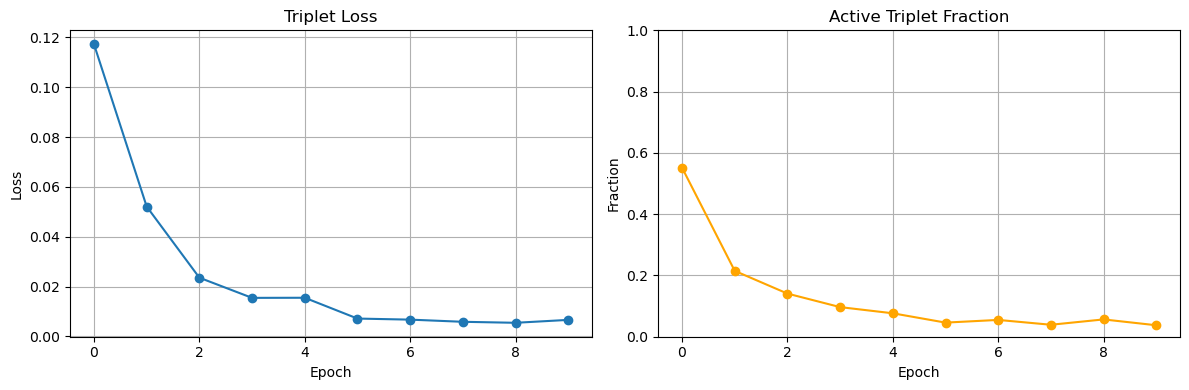

Training curve saved.


In [16]:
# ── Training Loop ─────────────────────────────────────────────────────────────
# Each epoch:
#   1. Forward pass: embed anchor, positive, negative
#   2. Compute triplet loss
#   3. Backward pass: compute gradients
#   4. Optimizer step: update unfrozen weights
#   5. Scheduler step: adjust LR

history = {"loss": [], "active_fraction": []}  # for plotting later
best_loss = float("inf")

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Margin: {TRIPLET_MARGIN} | LR backbone: {LR} | LR head: {LR_HEAD}\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss      = 0.0
    epoch_active    = 0.0
    num_batches     = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for anchors, positives, negatives, _ in pbar:
        # Move batch to GPU
        anchors   = anchors.to(DEVICE)
        positives = positives.to(DEVICE)
        negatives = negatives.to(DEVICE)

        # Zero gradients from previous step
        optimizer.zero_grad()

        # Forward pass — embed all three images
        emb_a = model(anchors)    # (batch, 128)
        emb_p = model(positives)  # (batch, 128)
        emb_n = model(negatives)  # (batch, 128)

        # Compute triplet loss
        loss, active_frac = criterion(emb_a, emb_p, emb_n)

        # Backward pass — compute gradients w.r.t. unfrozen parameters
        loss.backward()

        # Gradient clipping — prevents exploding gradients during fine-tuning
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        epoch_loss   += loss.item()
        epoch_active += active_frac
        num_batches  += 1

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "active": f"{active_frac:.2%}"
        })

    # Epoch-level stats
    avg_loss   = epoch_loss   / num_batches
    avg_active = epoch_active / num_batches
    history["loss"].append(avg_loss)
    history["active_fraction"].append(avg_active)

    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Active triplets: {avg_active:.2%} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save checkpoint if best loss so far
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), CKPT_DIR / "best_model.pth")
        print(f"  ✓ New best model saved (loss: {best_loss:.4f})")

print(f"\nTraining complete. Best loss: {best_loss:.4f}")

# Plot training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["loss"], marker="o")
ax1.set_title("Triplet Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(history["active_fraction"], marker="o", color="orange")
ax2.set_title("Active Triplet Fraction")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Fraction")
ax2.set_ylim(0, 1)
ax2.grid(True)

plt.tight_layout()
plt.savefig(EMB_DIR / "training_curve.png", dpi=150)
plt.show()
print("Training curve saved.")



---
## Section 6 — Embed All Crops & Build FAISS Index
Loads the best trained model, embeds every crop in the dataset, and builds a FAISS index.
This runs once — after this, retrieval is instant regardless of database size.

In [17]:
# ── Load best model ───────────────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_DIR / "best_model.pth", map_location=DEVICE))
model.eval()  # disable dropout and batch norm training mode
print("Best model loaded.")


# ── Embed all crops ───────────────────────────────────────────────────────────
# torch.no_grad() disables gradient computation — faster and uses less memory
# since we're only doing inference here

all_vectors  = []  # will become numpy array of shape (N, EMBED_DIM)
all_metadata = []  # parallel list of metadata dicts

print(f"Embedding {len(manifest)} crops...")
with torch.no_grad():
    for item in tqdm(manifest):
        try:
            img = Image.open(item["crop_path"]).convert("RGB")
            tensor = inference_transform(img).unsqueeze(0).to(DEVICE)  # (1, 3, 224, 224)
            embedding = model(tensor).squeeze(0).cpu().numpy()          # (128,)
            all_vectors.append(embedding)
            all_metadata.append(item)
        except Exception as e:
            print(f"Skipped {item['crop_path']}: {e}")

# Stack into a single numpy matrix: (N, EMBED_DIM)
vectors_matrix = np.vstack(all_vectors).astype("float32")
print(f"Embedding matrix shape: {vectors_matrix.shape}")

# Save to disk
np.save(EMB_DIR / "vectors.npy", vectors_matrix)
with open(EMB_DIR / "metadata.json", "w") as f:
    json.dump(all_metadata, f, indent=2)
print("Vectors and metadata saved.")

Best model loaded.
Embedding 358 crops...


100%|██████████| 358/358 [00:04<00:00, 80.37it/s]

Embedding matrix shape: (358, 128)
Vectors and metadata saved.


In [18]:
# ── Build FAISS Index ─────────────────────────────────────────────────────────
# FAISS (Facebook AI Similarity Search) does extremely fast nearest neighbor search.
#
# Index type: IndexFlatIP (Inner Product)
# Since our vectors are L2-normalized, inner product = cosine similarity.
# Higher score = more similar.
#
# For very large datasets (millions of vectors), switch to IndexIVFFlat or
# IndexHNSWFlat for approximate search — much faster at scale.

dimension = vectors_matrix.shape[1]  # EMBED_DIM = 128

# Build flat (exact) index
index = faiss.IndexFlatIP(dimension)

# Move index to GPU for faster search
# If this fails, remove these two lines and use CPU index
res   = faiss.StandardGpuResources()
index = faiss.index_cpu_to_gpu(res, 0, index)

# Add all vectors to the index
index.add(vectors_matrix)
print(f"FAISS index built. Vectors indexed: {index.ntotal}")

# Save index to disk (convert back to CPU first for serialization)
cpu_index = faiss.index_gpu_to_cpu(index)
faiss.write_index(cpu_index, str(INDEX_DIR / "faiss.index"))
print(f"Index saved to {INDEX_DIR / 'faiss.index'}")

FAISS index built. Vectors indexed: 358
Index saved to index\faiss.index


---
## Section 7 — Retrieval Demo
Given one query crop, finds the TOP_K most similar crops in the index.
Change `query_crop_path` to query with any crop from your crops folder.

Index, metadata and model loaded.
Query: bottle_0027_00.png


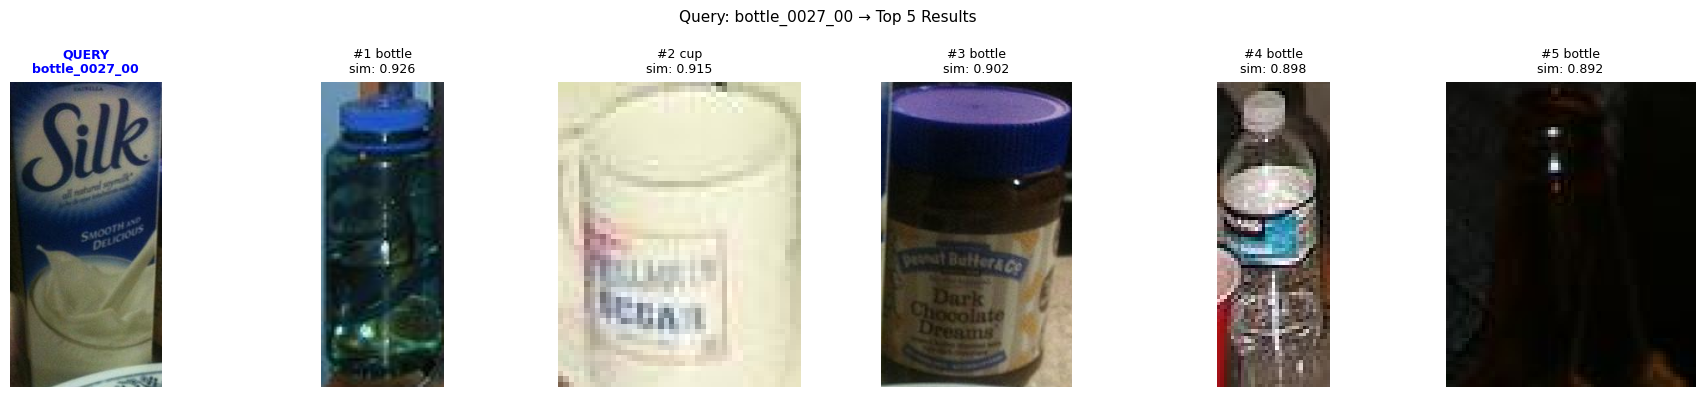


Results:
  #1 | class: bottle          | similarity: 0.9258 | bottle_0126_01.png
  #2 | class: cup             | similarity: 0.9147 | cup_0022_06.png
  #3 | class: bottle          | similarity: 0.9024 | bottle_0027_01.png
  #4 | class: bottle          | similarity: 0.8983 | bottle_0040_05.png
  #5 | class: bottle          | similarity: 0.8918 | bottle_0078_02.png


In [29]:
# ── Load index and metadata (skip if already in memory) ───────────────────────
cpu_index = faiss.read_index(str(INDEX_DIR / "faiss.index"))
res       = faiss.StandardGpuResources()
index     = faiss.index_cpu_to_gpu(res, 0, cpu_index)

with open(EMB_DIR / "metadata.json") as f:
    all_metadata = json.load(f)

model.load_state_dict(torch.load(CKPT_DIR / "best_model.pth", map_location=DEVICE))
model.eval()
print("Index, metadata and model loaded.")


# ── Helper: embed a single image ──────────────────────────────────────────────
def embed_image(img_path):
    """Load an image from disk and return its 128-dim embedding vector."""
    img    = Image.open(img_path).convert("RGB")
    tensor = inference_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        embedding = model(tensor).squeeze(0).cpu().numpy()
    return embedding.astype("float32")


# ── Helper: retrieve similar crops ───────────────────────────────────────────
def retrieve(query_path, top_k=TOP_K):
    """
    Embed the query image and find the top_k most similar crops in the index.
    Returns list of (metadata_dict, similarity_score).
    """
    query_vec = embed_image(query_path).reshape(1, -1)  # FAISS expects (1, dim)
    
    # FAISS returns distances and indices of nearest neighbors
    # For IndexFlatIP (inner product), higher score = more similar
    scores, indices = index.search(query_vec, top_k + 1)  # +1 to skip the query itself

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue  # FAISS returns -1 for empty slots
        meta = all_metadata[idx]
        # Skip if this result is the query image itself
        if meta["crop_path"] == str(query_path):
            continue
        results.append((meta, float(score)))
        if len(results) == top_k:
            break

    return results


# ── Run a query ───────────────────────────────────────────────────────────────
# Change this to any crop path from your crops/ folder
# Tip: look in crops/ and pick a class with many examples (person, car, etc.)
query_crop_path = sorted(CROPS_DIR.glob("*.png"))[0]  # default: first crop alphabetically
query_crop_path = sorted(CROPS_DIR.glob("bottle_0027_00.png"))[0]  # example: first crop of class "dog" (if exists)

print(f"Query: {query_crop_path.name}")
results = retrieve(query_crop_path, top_k=TOP_K)

# ── Display results ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, TOP_K + 1, figsize=(3 * (TOP_K + 1), 4))

# Query image
axes[0].imshow(Image.open(query_crop_path))
axes[0].set_title(f"QUERY\n{query_crop_path.stem[:20]}", fontsize=9, color="blue", fontweight="bold")
axes[0].axis("off")

# Add a vertical divider after query
axes[0].spines["right"].set_visible(True)
axes[0].spines["right"].set_linewidth(2)
axes[0].spines["right"].set_color("blue")

# Result images
for i, (meta, score) in enumerate(results):
    axes[i+1].imshow(Image.open(meta["crop_path"]))
    axes[i+1].set_title(
        f"#{i+1} {meta['class_name']}\nsim: {score:.3f}",
        fontsize=9
    )
    axes[i+1].axis("off")

plt.suptitle(f"Query: {query_crop_path.stem} → Top {TOP_K} Results", fontsize=11)
plt.tight_layout()
plt.savefig(EMB_DIR / "retrieval_result.png", dpi=150, bbox_inches="tight")
plt.show()

# Print similarity scores
print("\nResults:")
for i, (meta, score) in enumerate(results):
    print(f"  #{i+1} | class: {meta['class_name']:15s} | similarity: {score:.4f} | {Path(meta['crop_path']).name}")

---
## Section 8 — UMAP Visualization
Projects all 128-dim embedding vectors down to 2D and plots them colored by class.
Well-trained embeddings will show tight, separated clusters per class.

Loaded 358 vectors of dim 128
Running UMAP (this takes 1-2 minutes)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Tue May 19 15:46:02 2026 Construct fuzzy simplicial set


c:\Users\golde\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue May 19 15:46:03 2026 Finding Nearest Neighbors
Tue May 19 15:46:06 2026 Finished Nearest Neighbor Search
Tue May 19 15:46:09 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue May 19 15:46:10 2026 Finished embedding
UMAP complete. Output shape: (358, 2)


C:\Users\golde\AppData\Local\Temp\ipykernel_50016\2425192940.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_classes))


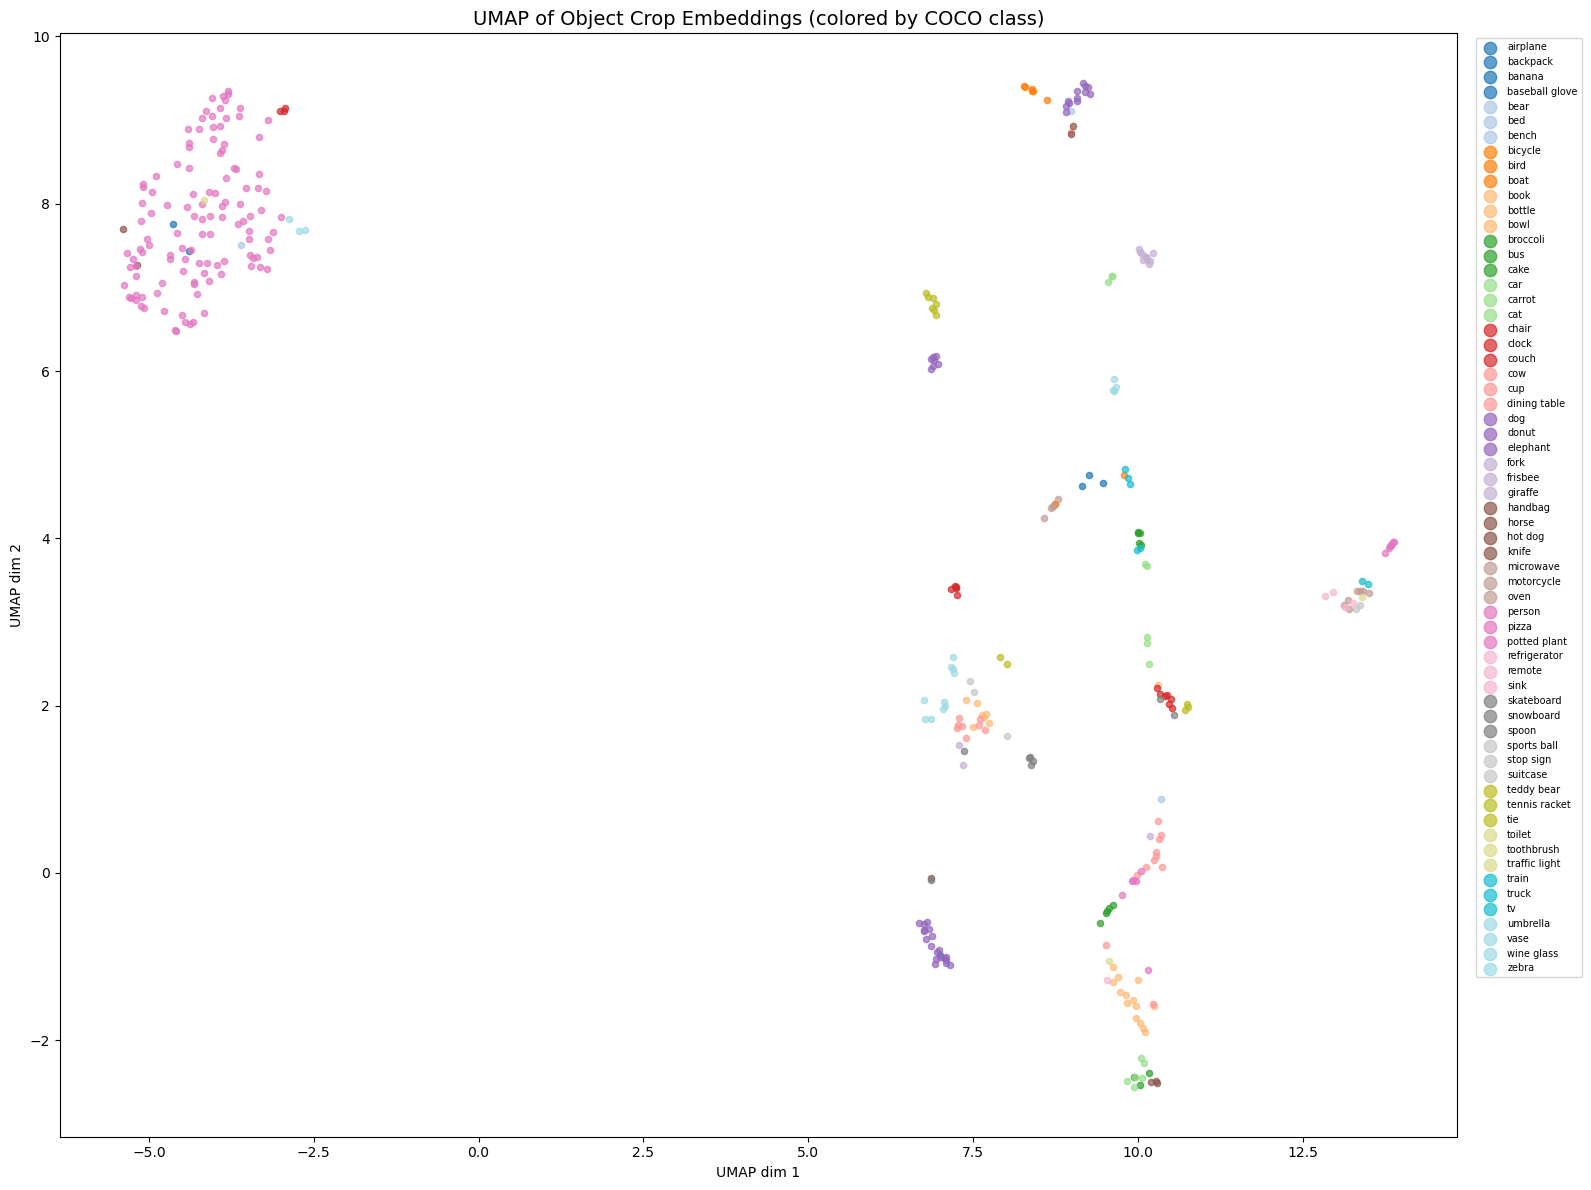

UMAP saved to embeddings\umap.png


In [20]:
# ── Load vectors and metadata ─────────────────────────────────────────────────
vectors_matrix = np.load(EMB_DIR / "vectors.npy")
with open(EMB_DIR / "metadata.json") as f:
    all_metadata = json.load(f)

class_names = [m["class_name"] for m in all_metadata]
class_ids   = [m["class_id"]   for m in all_metadata]

print(f"Loaded {vectors_matrix.shape[0]} vectors of dim {vectors_matrix.shape[1]}")


# ── Run UMAP ──────────────────────────────────────────────────────────────────
# UMAP reduces high-dimensional vectors to 2D while preserving local structure.
# n_neighbors: larger = more global structure preserved
# min_dist: smaller = tighter clusters
# metric: cosine works well for L2-normalized vectors

print("Running UMAP (this takes 1-2 minutes)...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    verbose=True
)
embedding_2d = reducer.fit_transform(vectors_matrix)  # (N, 2)
print(f"UMAP complete. Output shape: {embedding_2d.shape}")


# ── Plot ──────────────────────────────────────────────────────────────────────
unique_classes = sorted(set(class_names))
cmap = plt.cm.get_cmap("tab20", len(unique_classes))
class_to_color = {cls: cmap(i) for i, cls in enumerate(unique_classes)}

fig, ax = plt.subplots(figsize=(16, 12))

for cls in unique_classes:
    mask = np.array([c == cls for c in class_names])
    ax.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        c=[class_to_color[cls]],
        label=cls,
        s=20,
        alpha=0.7
    )

ax.set_title("UMAP of Object Crop Embeddings (colored by COCO class)", fontsize=14)
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=7,
    markerscale=2
)
plt.tight_layout()
plt.savefig(EMB_DIR / "umap.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"UMAP saved to {EMB_DIR / 'umap.png'}")

Crop A: bowl | bowl_0000_00.png
Crop B: broccoli | broccoli_0000_01.png

Embedding A (first 10 values): [     0.0878     -0.2033      0.0352     -0.0742      0.0147     -0.0421     -0.0056     -0.0489      0.0209      0.0542]
Embedding B (first 10 values): [     0.1134     -0.1467      0.0135     -0.1225      0.0515        0.02      0.0695     -0.0577     -0.0111      0.0073]

Cosine similarity: 0.7273
(1.0 = identical, 0.0 = orthogonal, -1.0 = opposite)


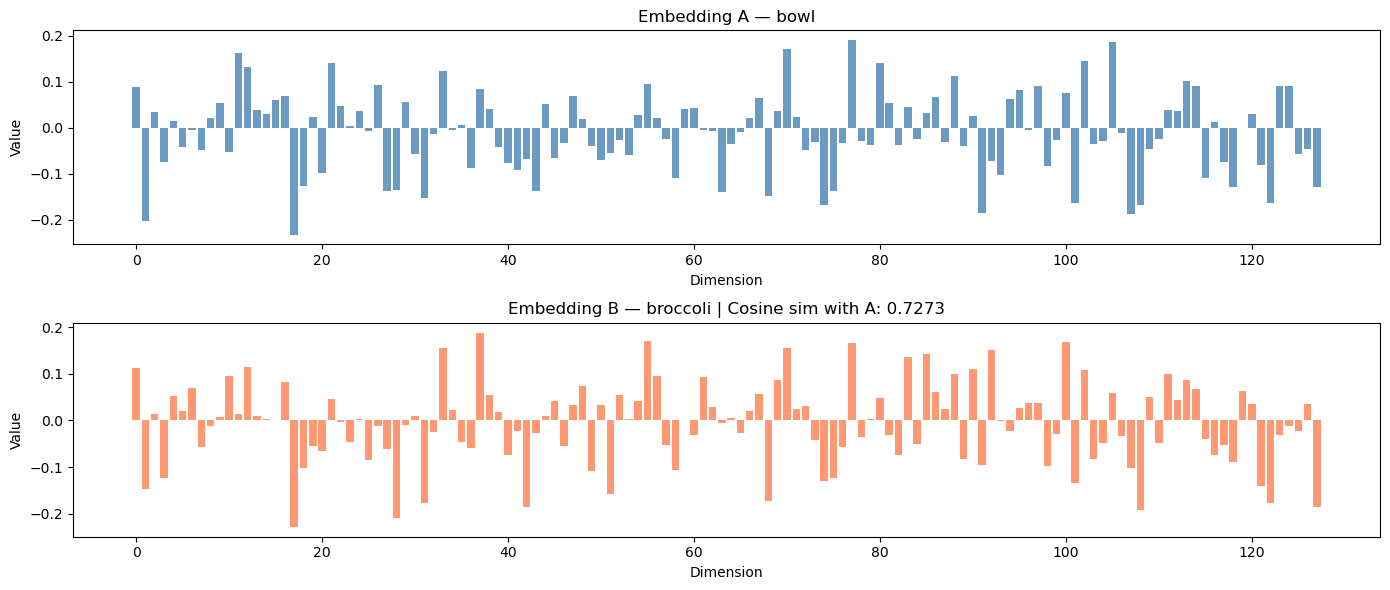

In [21]:
# ── BONUS: Show raw embedding values for a single crop ────────────────────────
# This is the actual vector the model produces — 128 floats on the unit sphere.
# Print values, plot as a bar chart, and show cosine similarity between two crops.

# Pick two crops to compare
idx_a = 0
idx_b = 1  # change to a crop of the same class for high similarity

vec_a = vectors_matrix[idx_a]
vec_b = vectors_matrix[idx_b]

cosine_sim = float(np.dot(vec_a, vec_b))  # equivalent to cosine sim since L2-normalized

print(f"Crop A: {all_metadata[idx_a]['class_name']} | {Path(all_metadata[idx_a]['crop_path']).name}")
print(f"Crop B: {all_metadata[idx_b]['class_name']} | {Path(all_metadata[idx_b]['crop_path']).name}")
print(f"\nEmbedding A (first 10 values): {vec_a[:10].round(4)}")
print(f"Embedding B (first 10 values): {vec_b[:10].round(4)}")
print(f"\nCosine similarity: {cosine_sim:.4f}")
print(f"(1.0 = identical, 0.0 = orthogonal, -1.0 = opposite)")

# Bar chart of embedding values
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].bar(range(EMBED_DIM), vec_a, color="steelblue", alpha=0.8)
axes[0].set_title(f"Embedding A — {all_metadata[idx_a]['class_name']}")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Value")

axes[1].bar(range(EMBED_DIM), vec_b, color="coral", alpha=0.8)
axes[1].set_title(f"Embedding B — {all_metadata[idx_b]['class_name']} | Cosine sim with A: {cosine_sim:.4f}")
axes[1].set_xlabel("Dimension")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.savefig(EMB_DIR / "embedding_values.png", dpi=150)
plt.show()